# Global Tsunami Events: 4,000 Years of Waves

2,547 tsunami events and 34,361 observed runup locations, cleaned from NOAA's Global Historical Tsunami Database. This is the third in a linked series alongside [Global Earthquakes 2020-2026](your-link) and [Global Volcanic Eruptions: Holocene Record](your-link) — many tsunamis in this dataset are directly triggered by events in those two.

This notebook explores:
- Where tsunamis originate and where their effects are felt
- How runup height relates to distance from the source
- How event confidence/validity varies across history
- Which events caused the most damage

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.rcParams["figure.facecolor"] = "#0d1117"
plt.rcParams["axes.facecolor"] = "#161b22"
plt.rcParams["axes.edgecolor"] = "#30363d"
plt.rcParams["axes.labelcolor"] = "white"
plt.rcParams["text.color"] = "white"
plt.rcParams["xtick.color"] = "#8b949e"
plt.rcParams["ytick.color"] = "#8b949e"
plt.rcParams["axes.titlecolor"] = "white"
plt.rcParams["grid.color"] = "#21262d"

events = pd.read_csv("/kaggle/input/datasets/zaneneave/global-tsunami-events-and-runups-historical-data/tsunami_events.csv")
runups = pd.read_csv("/kaggle/input/datasets/zaneneave/global-tsunami-events-and-runups-historical-data/tsunami_runups.csv")

print(f"{len(events):,} events, {len(runups):,} runups loaded")
events.head()

2,547 events, 34,361 runups loaded


,id,year,month,day,hour,minute,eventValidity,validity_label,causeCode,country,locationName,latitude,longitude,earthquakeEventId,volcanoEventId
0,1,-2000,NaN,NaN,NaN,NaN,1,very doubtful,1.0,SYRIA,SYRIAN COASTS,35.683,35.80,2.0,NaN
1,3,-1610,NaN,NaN,NaN,NaN,4,definite,6.0,GREECE,THERA ISLAND (SANTORINI),36.400,25.40,5877.0,1351.0
2,4,-1365,NaN,NaN,NaN,NaN,1,very doubtful,2.0,SYRIA,SYRIAN COASTS,35.683,35.80,9712.0,NaN
3,5,-1300,NaN,NaN,NaN,NaN,2,questionable,0.0,TURKEY,"IONIAN COASTS, TROAD",39.960,26.24,NaN,NaN
4,7,-590,NaN,NaN,NaN,NaN,2,questionable,1.0,LEBANON,LEBANON COASTS,33.270,35.22,7793.0,NaN


## Quick overview

Before mapping anything, worth seeing the shape of the data: how confident these event records typically are, how far back history goes and which countries appear most often.

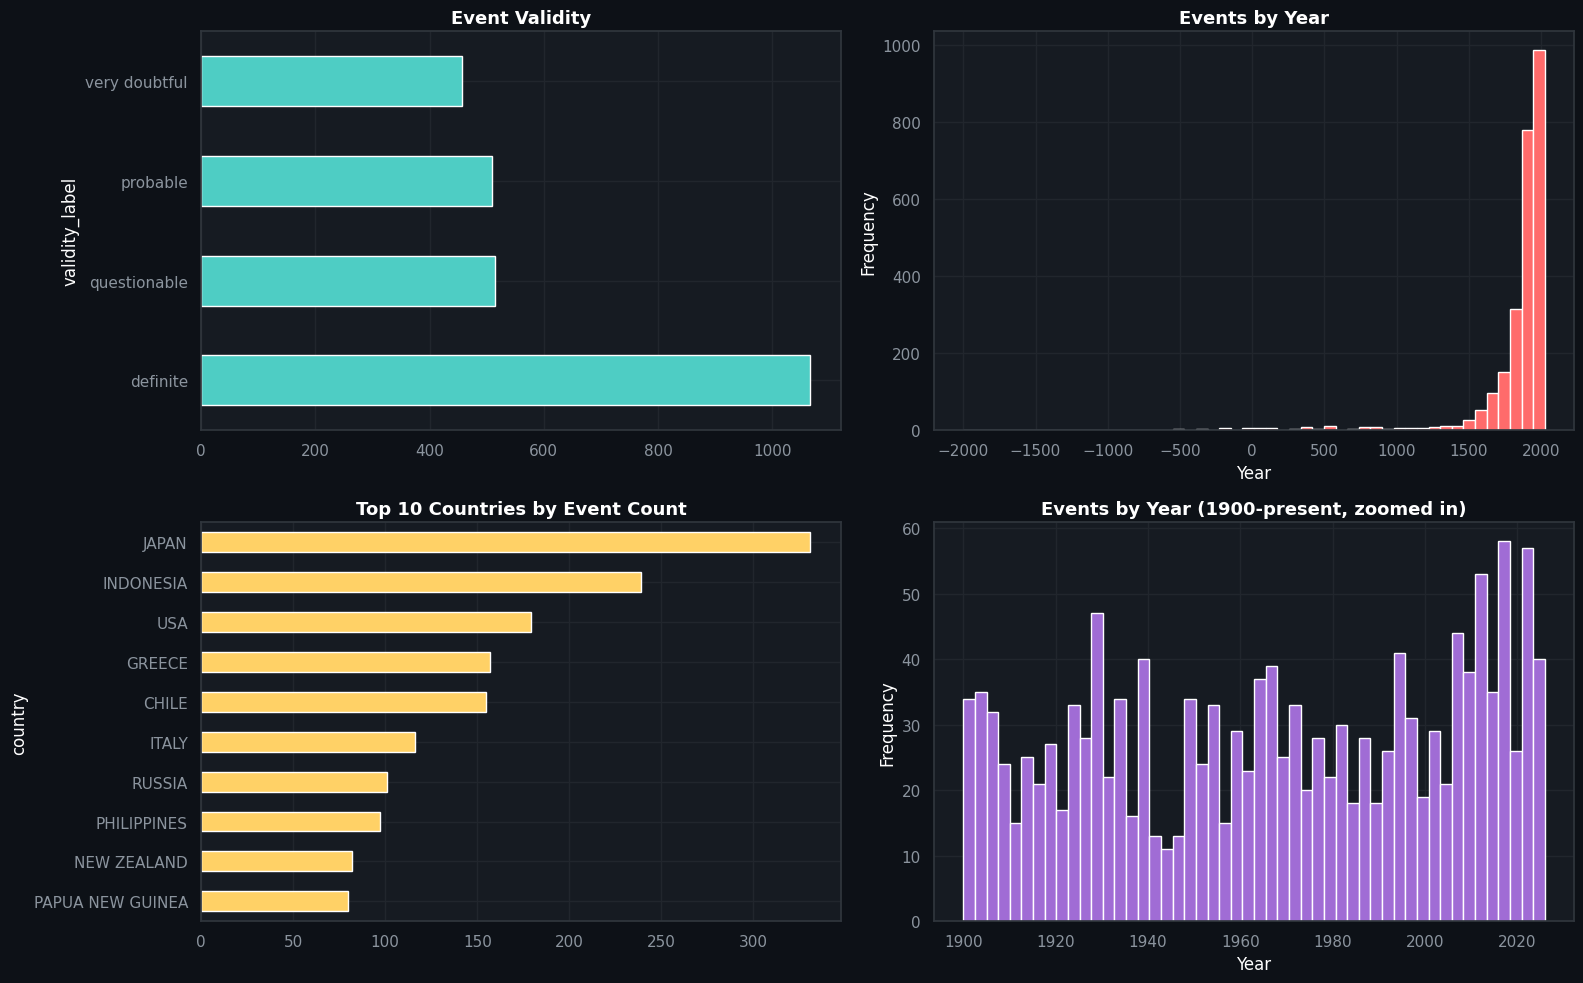

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

events["validity_label"].value_counts().plot(kind="barh", color="#4ecdc4", ax=axes[0,0])
axes[0,0].set_title("Event Validity", fontsize=13, fontweight="bold")

events["year"].plot(kind="hist", bins=50, color="#ff6b6b", ax=axes[0,1])
axes[0,1].set_title("Events by Year", fontsize=13, fontweight="bold")
axes[0,1].set_xlabel("Year")

events["country"].value_counts().head(10).plot(kind="barh", color="#ffd166", ax=axes[1,0])
axes[1,0].invert_yaxis()
axes[1,0].set_title("Top 10 Countries by Event Count", fontsize=13, fontweight="bold")

recent = events[events["year"] >= 1900]
recent["year"].plot(kind="hist", bins=50, color="#a06cd5", ax=axes[1,1])
axes[1,1].set_title("Events by Year (1900-present, zoomed in)", fontsize=13, fontweight="bold")
axes[1,1].set_xlabel("Year")

plt.tight_layout()
plt.show()

### A steep, expected curve and a countries list that tells its own story

**Event validity**: "definite" is the largest category (~1,070), which is reassuring — the majority of recorded events are confidently verified, not speculative.

**Events by year**: an extremely steep skew toward modern history — barely any events before 1500, then a sharp climb from 1700 onward, peaking hard near 2000-2026. This is almost certainly a **detection/recording bias, not a real increase in tsunami frequency**. Ancient tsunamis simply weren't systematically documented; modern seismic networks and tide gauges catch nearly everything today. Worth stating this plainly rather than implying tsunamis are becoming more frequent.

**Zoomed-in 1900-present view**: shows real texture once ancient history is filtered out — noisy year-to-year, but recent decades (2010s-2020s) do show higher counts than earlier in the 20th century. Again, this likely reflects improved monitoring infrastructure (more coastal sensors, better global earthquake detection) rather than genuinely more tsunamis occurring.

**Top countries**: Japan and Indonesia lead by a wide margin — both sit directly on major subduction zones (the same regions that dominated the earthquake and volcano maps in this series), which is a nice consistency check across all three datasets rather than a coincidence.

## Where do tsunamis originate?

Same mapping approach as the earlier datasets in this series — plotting every event by coordinates, colored by validity level this time instead of magnitude.

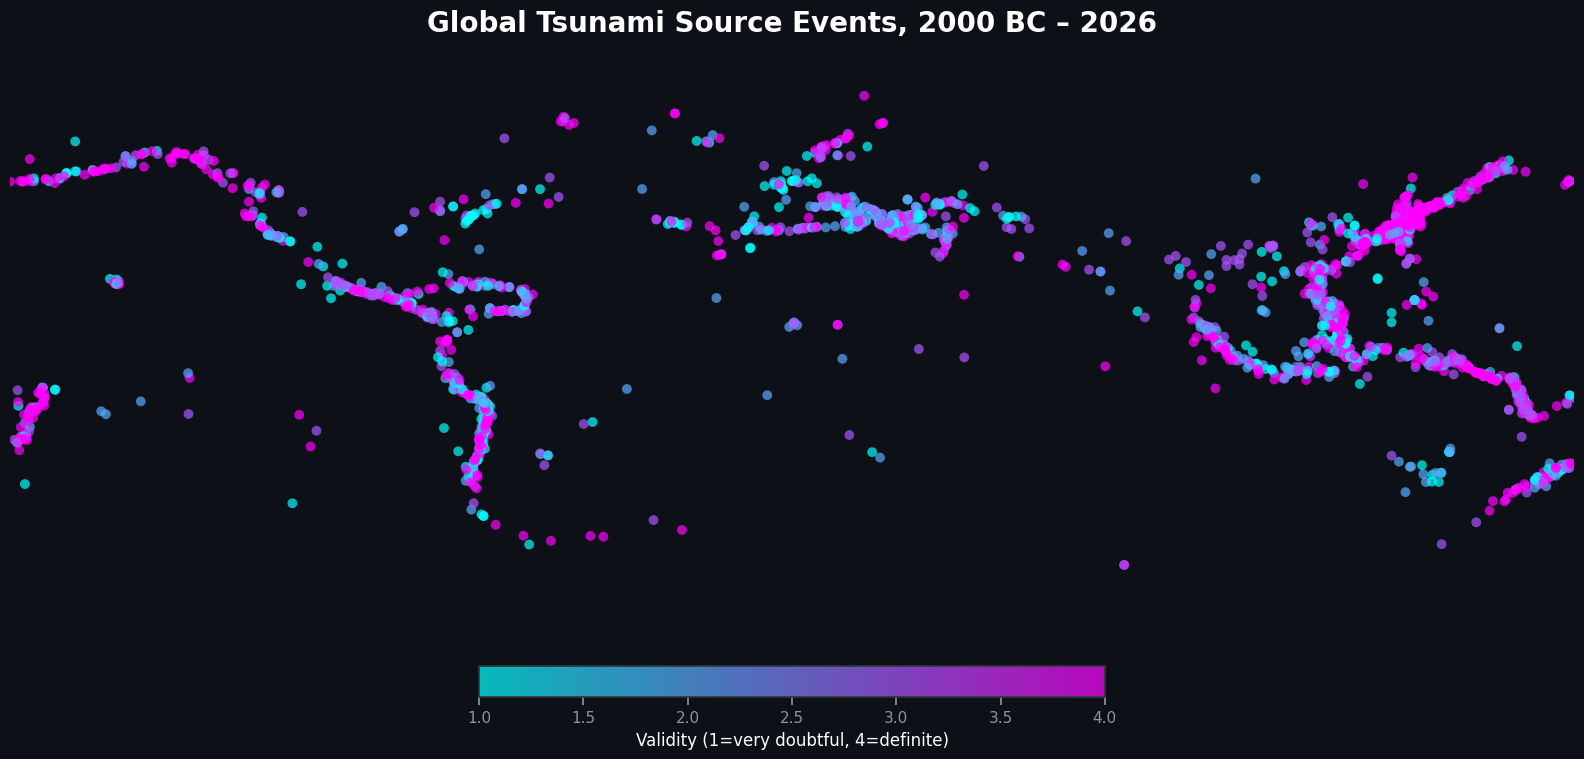

In [3]:
plot_events = events.dropna(subset=["latitude", "longitude"])

fig, ax = plt.subplots(figsize=(16, 8), facecolor="#0d1117")
ax.set_facecolor("#0d1117")

scatter = ax.scatter(
    plot_events["longitude"], plot_events["latitude"],
    s=50, c=plot_events["eventValidity"], cmap="cool", alpha=0.7, edgecolors="none"
)
ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

cbar = plt.colorbar(scatter, ax=ax, orientation="horizontal", pad=0.05, shrink=0.4)
cbar.set_label("Validity (1=very doubtful, 4=definite)", color="white")

ax.set_title("Global Tsunami Source Events, 2000 BC – 2026", 
             color="white", fontsize=20, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

### The Ring of Fire, once again and a hint that isolated events skew less confident

The Pacific Rim dominates the map exactly as it did in the earthquake and volcano datasets — this makes complete sense, since the majority of tsunamis are earthquake triggered and the Pacific hosts the highest concentration of subduction-zone quakes.

**One pattern worth calling out honestly**: the isolated, scattered dots far from the main belts (open ocean, mid-continent-adjacent coastlines) skew noticeably more toward cyan/blue (lower validity) than the tightly-packed belts, which lean magenta/pink (higher validity, closer to 4). This makes sense — well-monitored, densely-populated coastal regions along major fault lines have much better historical documentation, so events there are more likely to be confidently verified. Isolated claims from sparser regions or older records are inherently harder to confirm.

**Consistent with the whole series so far**: this is the third dataset in a row where the same handful of subduction zones (Pacific Rim, Mediterranean, Indonesia) show up as the dominant global hotspot — a nice cross-validation that all three datasets are capturing the same underlying physical reality from different angles.

## Does runup height relate to distance from the source?

Intuitively, tsunami waves should lose energy as they travel — worth checking whether that shows up clearly in the runup data or whether local coastal geography (which this simple relationship ignores) muddies the picture.

Min distFromSource: 0.0
Rows with distFromSource <= 0: 40


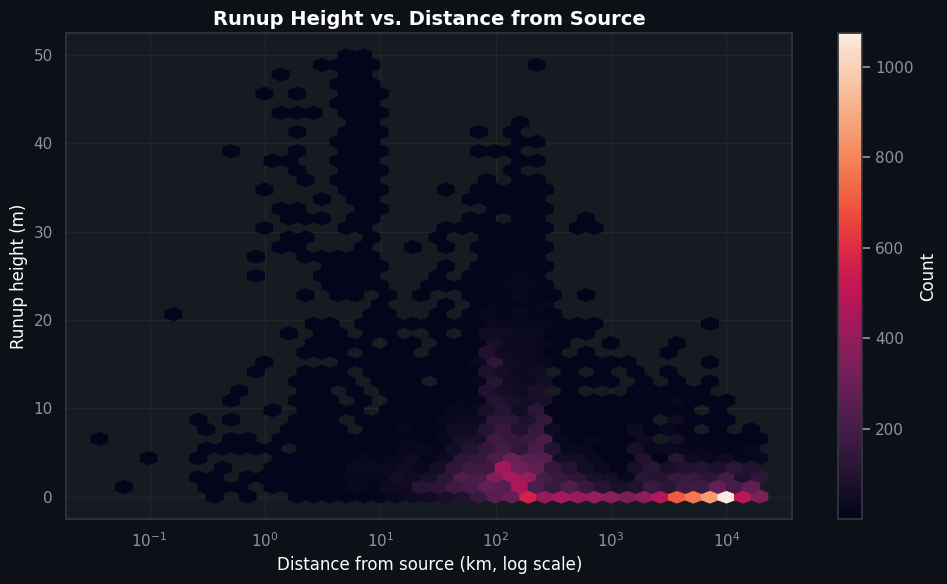

Correlation (log distance, runup height): -0.389


In [4]:
plot_runups = runups.dropna(subset=["distFromSource", "runupHt"])
plot_runups = plot_runups[(plot_runups["runupHt"] > 0) & (plot_runups["runupHt"] < 50)]

print("Min distFromSource:", plot_runups["distFromSource"].min())
print("Rows with distFromSource <= 0:", (plot_runups["distFromSource"] <= 0).sum())

plot_runups = plot_runups[plot_runups["distFromSource"] > 0]

plt.figure(figsize=(10, 6))
plt.hexbin(plot_runups["distFromSource"], plot_runups["runupHt"], gridsize=40, cmap="rocket", mincnt=1, xscale="log")
plt.xlabel("Distance from source (km, log scale)")
plt.ylabel("Runup height (m)")
plt.title("Runup Height vs. Distance from Source", fontsize=14, fontweight="bold")
plt.colorbar(label="Count")
plt.tight_layout()
plt.show()

print("Correlation (log distance, runup height):", 
      np.corrcoef(np.log1p(plot_runups["distFromSource"]), plot_runups["runupHt"])[0,1].round(3))

### Runup height does decay with distance but with huge scatter

Correlation of -0.389 confirms a real, moderate negative relationship: tsunami waves generally do lose height as they travel farther from the source, exactly as physical intuition suggests.

But the hexbin reveals something the correlation number alone hides: **there's a dense cluster of very low runup heights spanning the entire distance range**, right along the bottom of the plot from 10km all the way out to 10,000km+. This means a huge number of runup observations recorded minimal wave height regardless of distance likely locations that were technically within the tsunami's reach but experienced negligible actual impact.

**At close range (10-100km), there's real spread** — some locations saw massive 40-50m runups while others just a few km away saw almost nothing. This is a genuine, well-documented tsunami phenomenon: local coastline shape (bays, inlets, harbor geometry) can dramatically amplify or dampen wave height independent of distance, which is exactly what's showing up here as scatter rather than a clean decay curve.

**Honest takeaway**: distance from source explains part of the picture (hence the real, moderate correlation), but local geography clearly plays a major role too, a single "decay with distance" model would badly oversimplify what's actually a much more localized, coastline-dependent phenomenon.

## Can we predict runup height from distance, travel time, and location?

Distance alone gave a moderate correlation (-0.389) but lots of scatter. Let's see if adding travel time and location as proxies for regional coastal geography improves things meaningfully.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

ml_features = ["distFromSource", "travHours", "travMins", "latitude", "longitude"]
ml_df = runups.dropna(subset=ml_features + ["runupHt"]).copy()
ml_df = ml_df[(ml_df["runupHt"] > 0) & (ml_df["runupHt"] < 50) & (ml_df["distFromSource"] > 0)]

print(f"Rows available for modeling: {len(ml_df):,}")

X = ml_df[ml_features]
y = ml_df["runupHt"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training on {len(X_train):,}, testing on {len(X_test):,}")

Rows available for modeling: 3,752
Training on 3,001, testing on 751


In [6]:
model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)
baseline_mae = mean_absolute_error(y_test, [y_train.mean()] * len(y_test))

print(f"Model MAE: {mae:.2f} meters")
print(f"Model R²: {r2:.3f}")
print(f"Baseline (predict mean) MAE: {baseline_mae:.2f}")
print(f"Improvement over baseline: {(baseline_mae - mae):.2f}")

Model MAE: 0.50 meters
Model R²: 0.155
Baseline (predict mean) MAE: 0.63
Improvement over baseline: 0.13


### Weak but real signal — location and travel time only partially substitute for local geography

R² of 0.155 means these features explain about 15.5% of the variance in runup height, noticeably weaker than the -0.389 correlation with distance alone might have suggested, though that's expected since correlation and R² aren't directly comparable and the model is now working with a smaller, stricter subset of rows (those with complete travel time data).

The model still meaningfully beats the baseline (MAE 0.50m vs 0.63m, about 21% better than just guessing the average), confirming genuine predictive signal exists but it's far from a reliable prediction tool.

**Why this ceiling makes sense**: as the hexbin plot showed, runup height is heavily shaped by local coastline geometry — bay shape, harbor funneling, offshore bathymetry none of which is captured by distance, travel time, or raw lat/lon coordinates. Latitude/longitude tell you roughly *which region* a location is in, but not the specific coastal features that actually determine wave amplification. This is a case where the real driver of the outcome (local topography) simply isn't present in the available features, capping how well any model can do regardless of algorithm choice.

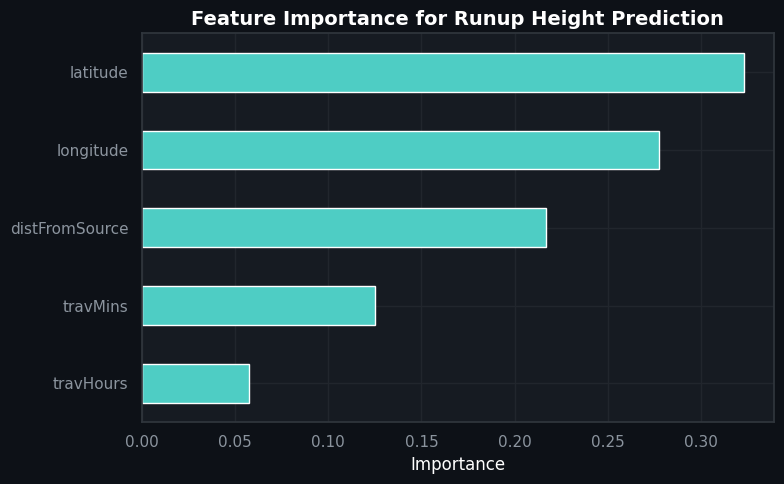

latitude          0.322916
longitude         0.277585
distFromSource    0.216874
travMins          0.124912
travHours         0.057713
dtype: float64


In [7]:
importances = pd.Series(model.feature_importances_, index=ml_features).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.plot(kind="barh", color="#4ecdc4")
plt.title("Feature Importance for Runup Height Prediction", fontsize=14, fontweight="bold")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(importances)

### Location matters more than distance a real, if modest, finding

Latitude and longitude together account for over 60% of the model's predictive power, outweighing `distFromSource` (21.7%) and travel time (18.2% combined). This actually makes sense on reflection: **where** a runup was observed captures real information that plain distance can't, certain regions (specific bays, harbors, island chains) are known to consistently produce amplified runups regardless of how far the source was, while others consistently dampen them.

**This reframes the earlier finding**: it's not that distance from source doesn't matter it clearly does, both in the correlation and the model. But the model is essentially learning "some coastlines are just more dangerous than others," using raw coordinates as a rough stand-in for real coastal geography data (bathymetry, bay shape, etc.) that this dataset simply doesn't include.

**A natural extension** (not done here, but worth mentioning): a model with access to actual bathymetric/coastal-shape data would likely perform substantially better than this one, the ceiling here reflects a genuine data limitation, not a dead end for the underlying question.

## Have fun